# 06 · Reproducibility, validation optimism and other pitfalls

The last tutorial is about trusting the numbers. It covers how seeding works, why the
validation score is optimistic, why a single split is a noisy estimate, and how to save
and reload a tuned model.

In [1]:
import warnings

warnings.filterwarnings("ignore")  # hide convergence and progress-bar warnings in tutorial output

import optuna

optuna.logging.set_verbosity(optuna.logging.ERROR)  # Optuna otherwise logs every trial, and a traceback per failed one

In [2]:
import matplotlib.pyplot as plt

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]  # categorical palette, used in this fixed order
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"


def tidy(ax, title, xlabel, ylabel):
    """Recessive axes and grid so the data, not the frame, carries the chart."""
    ax.set_title(title, loc="left", color=INK, fontsize=12, pad=12)
    ax.set_xlabel(xlabel, color=INK_2)
    ax.set_ylabel(ylabel, color=INK_2)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2)
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)

## 1. Seeds come from the experiment name

`experiment_name` is hashed (MD5) into a 32-bit seed that drives the splits, the Optuna
sampler and every estimator that accepts `random_state`. The hash is stable across
processes, machines and operating systems, so a name is a complete description of a run.

In [3]:
from sklearn.datasets import make_classification

from mloptune import FineTuneConfig, FineTuner
from mloptune.framework import _build_seed

X, y = make_classification(n_samples=600, n_features=20, n_informative=5, n_redundant=3, flip_y=0.15, random_state=7)

for name in ("experiment-a", "experiment-a", "experiment-b"):
    print(f"{name:14s} -> seed {_build_seed(name)}")

experiment-a   -> seed 1190936874
experiment-a   -> seed 1190936874
experiment-b   -> seed 1492918062


In [4]:
SEARCH_SPACE = {"max_depth": {"type": "int", "low": 1, "high": 20},
                "min_samples_leaf": {"type": "int", "low": 1, "high": 30}}


def make_config(name, n_trials=10, **overrides):
    return FineTuneConfig("DecisionTreeClassifier", "classification", name,
                          n_trials=n_trials, search_space=SEARCH_SPACE, **overrides)


def run(name, n_trials=10, **overrides):
    return FineTuner(make_config(name, n_trials, **overrides)).run(X, y)

first, second, other = run("experiment-a"), run("experiment-a"), run("experiment-b")
print("same name, run twice  :", first.best_params == second.best_params and first.test_score == second.test_score)
print("different name        :", other.best_params, "vs", first.best_params)

same name, run twice  : True
different name        : {'max_depth': 6, 'min_samples_leaf': 19} vs {'max_depth': 18, 'min_samples_leaf': 19}


To override the estimator seed only, pass `random_state` in `model_kwargs`. Passing
`random_state=None` there makes the estimator non-deterministic on purpose.

## 2. The validation score is optimistic

"The performance will usually be slightly worse than what you measured using
cross-validation if you did a lot of hyperparameter tuning, because your system ends up
fine-tuned to perform well on the validation data" (chapter 2).

`validation_score` is the **best of N** trial scores on one validation split. The more
trials, the more it drifts up, whether or not the test score follows. Same split every
time below, only the budget changes.

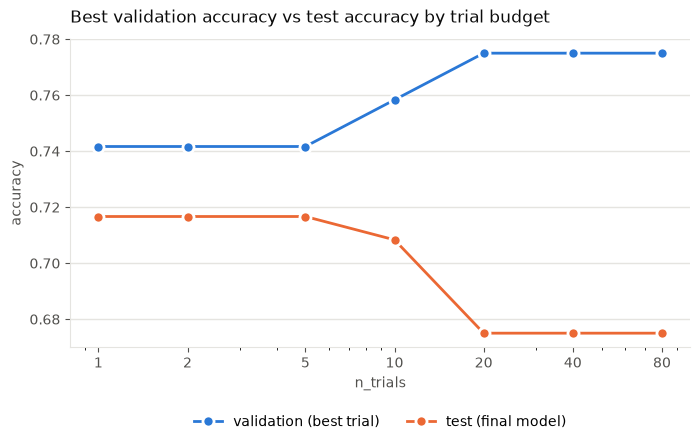

In [5]:
budgets = [1, 2, 5, 10, 20, 40, 80]
sweep = {n: run("tutorial-06-optimism", n_trials=n, n_startup_trials=5) for n in budgets}

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(budgets, [sweep[n].validation_score for n in budgets], color=SERIES[0], linewidth=2, marker="o",
        markersize=8, markeredgecolor="white", markeredgewidth=2, label="validation (best trial)")
ax.plot(budgets, [sweep[n].test_score for n in budgets], color=SERIES[1], linewidth=2, marker="o",
        markersize=8, markeredgecolor="white", markeredgewidth=2, label="test (final model)")
ax.set_xscale("log")
ax.set_xticks(budgets)
ax.set_xticklabels(budgets)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
tidy(ax, "Best validation accuracy vs test accuracy by trial budget", "n_trials", "accuracy")
plt.show()

In this run the test accuracy even drops as the budget grows: the extra trials find
hyperparameters that fit the quirks of the validation split, not the signal.

Report `test_score`. Treat `validation_score` as a selection statistic, not an estimate of
generalization. And resist re-running with new search spaces until the *test* number
looks good: that turns the test split into a second validation split.

## 3. One split is a noisy estimate

Chapter 1: "if the validation set is too small, then model evaluations will be imprecise".
The same holds for the test split. Different experiment names give different splits; the
spread in test scores is the noise floor you are comparing models against.

In [6]:
import numpy as np

test_scores = [run(f"tutorial-06-split-{i}", n_trials=10).test_score for i in range(8)]
print("test accuracies over 8 different splits:", np.round(test_scores, 3))
print(f"mean={np.mean(test_scores):.3f}  std={np.std(test_scores, ddof=1):.3f}  range={np.ptp(test_scores):.3f}")

test accuracies over 8 different splits: [0.717 0.658 0.742 0.625 0.783 0.708 0.717 0.692]
mean=0.705  std=0.049  range=0.158


If two models differ by less than that spread, you have not shown one is better.
Larger `test_size` and `validation_size` reduce the noise at the cost of training data;
repeated cross-validation, which the book recommends for small datasets, is the next
step beyond what `mloptune` currently does.

## 4. Random search unless you give TPE room

Repeated from tutorial 02 because it is the most common surprise: Optuna's first
`n_startup_trials` (default 10) are random. With `n_trials=10` nothing is model-based.

In [7]:
from optuna.samplers import TPESampler

defaults = run("tutorial-06-optimism", n_trials=10)
print("default sampler startup trials:", defaults.study.sampler._n_startup_trials, "of", len(defaults.study.trials), "trials")
tuned = run("tutorial-06-optimism", n_trials=30, n_startup_trials=8)
print("with n_startup_trials=8       :", tuned.study.sampler._n_startup_trials, "of", len(tuned.study.trials), "trials")

default sampler startup trials: 10 of 10 trials
with n_startup_trials=8       : 8 of 30 trials


## 5. Save the model, and the config that produced it

The book: "save every model you experiment with ... both the hyperparameters and the
trained parameters". `joblib` handles the estimator; the config is a frozen dataclass
that `dataclasses.asdict` turns into plain JSON.

In [8]:
import dataclasses
import json
import tempfile
from pathlib import Path

import joblib

best = sweep[40]
out = Path(tempfile.mkdtemp())
joblib.dump(best.model, out / "model.joblib")
(out / "run.json").write_text(json.dumps({
    "config": dataclasses.asdict(make_config("tutorial-06-optimism", n_trials=40, n_startup_trials=5)),
    "seed": best.seed,
    "best_params": best.best_params,
    "validation_score": best.validation_score,
    "test_score": best.test_score,
}, indent=2))

reloaded = joblib.load(out / "model.joblib")
print("reloaded predictions match:", (reloaded.predict(X[:50]) == best.model.predict(X[:50])).all())
print((out / "run.json").read_text()[:300], "...")

reloaded predictions match: True
{
  "config": {
    "model_name": "DecisionTreeClassifier",
    "problem_type": "classification",
    "experiment_name": "tutorial-06-optimism",
    "test_size": 0.2,
    "validation_size": 0.2,
    "scoring": null,
    "n_trials": 40,
    "search_space": {
      "max_depth": {
        "type": "int" ...


## 6. Checklist

- [ ] `problem_type` matches the model, `scoring` matches the cost of errors.
- [ ] `n_trials` well above `n_startup_trials`, or `n_startup_trials` lowered.
- [ ] Same `experiment_name` for every model you want to compare.
- [ ] Report `test_score` with an interval; treat `validation_score` as selection only.
- [ ] Save the model and the config together.
- [ ] Stop tuning once you have looked at the test score.